In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

CSV = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe.csv"
df = pd.read_csv(CSV)

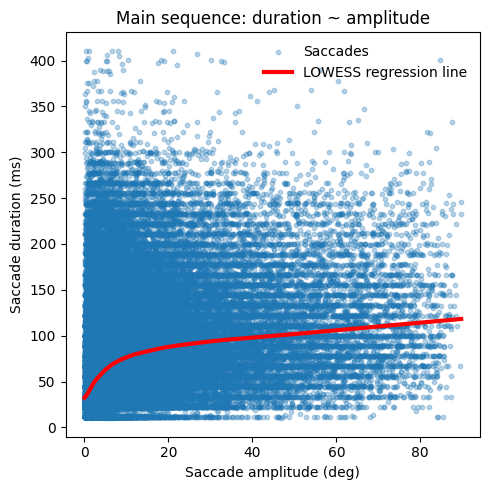

In [5]:
AMP = "saccade_amplitude_deg"
LEN = "length"         # seconds (on saccade onset rows)
EVENT = "events"       # 1 = saccade onset

# Only valid onsets that have both amplitude and duration
mask = (df[EVENT] == 1.0) & df[AMP].notna() & df[LEN].notna()
d = df.loc[mask, [AMP, LEN]].copy()
d["dur_ms"] = d[LEN] * 1000.0  # convert to ms

# ---------------- Plot with LOWESS ----------------
plt.figure(figsize=(5, 5))

# Scatter of raw data
plt.scatter(d[AMP], d["dur_ms"], s=10, alpha=0.3, label="Saccades")

# LOWESS smoothed fit
frac = 0.2 # can be adjusted for smoothness
lowess_fit = lowess(d["dur_ms"], d[AMP], frac=frac, return_sorted=True)

# Plot the LOWESS trend line
plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], color="red", lw=3, label=f"LOWESS regression line")

# Labels and style
plt.xlabel("Saccade amplitude (deg)")
plt.ylabel("Saccade duration (ms)")
plt.title("Main sequence: duration ~ amplitude")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


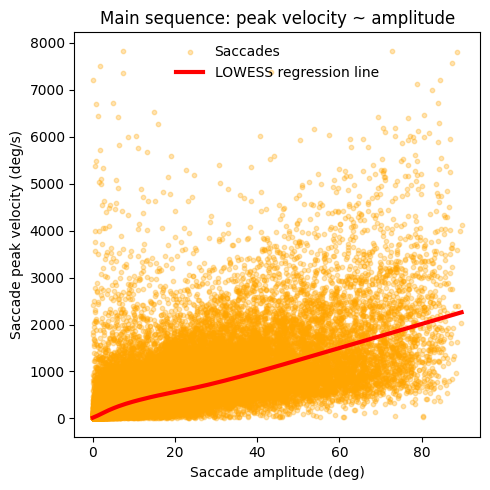

In [2]:
AMP   = "saccade_amplitude_deg"                 # degrees
PEAKV = "saccade_peak_velocity_deg_per_s"       # deg/s
EVENT = "events"                                # 1 = saccade onset

# Keep valid saccade onsets with both amplitude and peak velocity present
mask = (df[EVENT] == 1.0) & df[AMP].notna() & df[PEAKV].notna()
d = df.loc[mask, [AMP, PEAKV]].copy()

# ---------------- Plot with LOWESS ----------------
plt.figure(figsize=(5, 5))

# Scatter of raw data (orange points)
plt.scatter(d[AMP], d[PEAKV], s=10, alpha=0.3, color="orange", label="Saccades")

# LOWESS smoothed fit
frac = 0.2
lowess_fit = lowess(d[PEAKV], d[AMP], frac=frac, return_sorted=True)

# Plot the LOWESS trend line
plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], color="red", lw=3, label="LOWESS regression line")

# Labels and style
plt.xlabel("Saccade amplitude (deg)")
plt.ylabel("Saccade peak velocity (deg/s)")
plt.title("Main sequence: peak velocity ~ amplitude")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()